In [6]:
import fastf1
import pandas as pd
import numpy as np
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

# use the data stored locally
fastf1.Cache.enable_cache('../data/raw')

def load_and_clean_race(year, race_name):

    # load the race
    session = fastf1.get_session(year, race_name, 'R')
    session.load()

    laps_og = session.laps
    laps = laps_og.copy()

    # add Race_ID to track which event these laps belong to when scaled
    laps['Race_ID'] = f"{year}_{race_name}"

    # DYNAMIC FUEL BURN ######################################################
    # calculate on all laps before eliminating safety car/inter laps!!!!!!!!!!!!

    # get slow laps = safety car, VSC, pit in/out
    is_slow_lap = (
        laps['TrackStatus'].str.contains('4|6', na=False, regex=True) | 
        laps['PitInTime'].notnull() | 
        laps['PitOutTime'].notnull()
    )

    # 0.4kg for slow laps, 1.7kg for normal racing laps
    laps['Dynamic_Burn'] = np.where(is_slow_lap, 0.4, 1.7)
    laps['Cumulative_Fuel_Burn'] = laps.groupby('Driver')['Dynamic_Burn'].cumsum()
    # calc dynamic mass
    laps['Estimated_Fuel_Mass'] = 105.0 - laps['Cumulative_Fuel_Burn']

    # keep only DRY compounds = drop any WET compounds
    laps = laps[laps['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])]

    # drop incomplete/inaccurate laps - safety car laps, pit laps
    clean_laps = laps[laps['IsAccurate'] == True]
    clean_laps = clean_laps[clean_laps['PitInTime'].isnull() & clean_laps['PitOutTime'].isnull()]
    clean_laps = clean_laps[~clean_laps['TrackStatus'].str.contains('4|6', na=False, regex=True)]

    # create Stint_ID - Cross-Validation Grouping Key
    # a 'STINT' is a continuous run on one set of tires
    # combine Driver's 3-letter code +  their integer Stint number
    clean_laps['Stint_ID'] = clean_laps['Driver'] + "_Stint_" + clean_laps['Stint'].astype(int).astype(str)

    # define the target variable
    clean_laps['Target_Compound'] = clean_laps['Compound']

    # convert LapTime from ns to s
    clean_laps['LapTime_Sec'] = clean_laps['LapTime'].dt.total_seconds()

    # get race progression feature
    total_laps = session.total_laps 
    clean_laps['Race_Progression'] = clean_laps['LapNumber'] / total_laps

    print(f"Original laps: {len(laps)}")

    return clean_laps, session


def calculate_baseline_pace(clean_laps):
    top3_avg = (
        clean_laps.groupby('LapNumber')['LapTime_Sec']
        .nsmallest(3)                # top 3 fastest times
        .groupby('LapNumber')          # regroup by LapNumber
        .mean()                       # average those 3 times
        .reset_index()
    )
    top3_avg.rename(columns={'LapTime_Sec': 'Top3_Avg_Sec'}, inplace=True)

    # sort by LapNumber to ensure chronological order
    top3_avg = top3_avg.sort_values('LapNumber')

    # Exponential Moving Average (EMA) to smooth out spikes
    # span=5 -> EMA gives the most weight to the last 5 laps = approx 7-10 mins of track time
    top3_avg['Field_Best_Lap_Sec'] = top3_avg['Top3_Avg_Sec'].ewm(span=5, adjust=False).mean()

    smoothed_baseline = top3_avg[['LapNumber', 'Field_Best_Lap_Sec']]
    clean_laps = clean_laps.merge(smoothed_baseline, on='LapNumber', how='left')

    # calc DELTA: how much slower was this driver compared to the smoothed track evolution curve
    clean_laps['Delta_to_Field_Best'] = clean_laps['LapTime_Sec'] - clean_laps['Field_Best_Lap_Sec']

    print(f"Clean laps remaining: {len(clean_laps)}")
    # print(clean_laps.head())

    return clean_laps

#################################################################### TELEMTRY AND FEATURE ENGINEERING ######################################################################

# logic for only one lap
def process_single_lap(lap_tuple):
    index, lap = lap_tuple
    try:
        tel = lap.get_telemetry()
        
        avg_speed = tel['Speed'].mean()
        std_dev_speed = tel['Speed'].std()
        min_speed = tel['Speed'].min() # abs slower point on track = thightest hairpin
        corner_speed_10th = tel['Speed'].quantile(0.10)  # proxy for low-speed cornering across multiple corners
        avg_rpm = tel['RPM'].mean()
        avg_throttle = tel['Throttle'].mean()
        percent_full_throttle = (tel['Throttle'] >= 99).mean()
        
        # BRAKE EVENTS = how many times the brake pedal goes from 0 to >0 
        brake_transitions = (tel['Brake'] > 0).astype(int).diff()
        brake_events = (brake_transitions == 1).sum()
        
        # DIRTY AIR / TRAFFIC PROXY ###################################
        # convert km/h to m/s 
        # replace 0 with 0.001 to avoid division by 0
        speed_ms = (tel['Speed'] / 3.6).replace(0, 0.001)

        # calc dynamic time gap to car ahead -> Distance / Speed = Time
        tel['Time_Gap_Ahead'] = tel['DistanceToDriverAhead'] / speed_ms
        
        # check when car is within 2.5 seconds = dirty air zone
        # check >0 for when no car ahead
        in_dirty_air = (tel['Time_Gap_Ahead'] > 0) & (tel['Time_Gap_Ahead'] <= 2.5)

        # dliding / cornering in dirty air
        # condition: in dirty air && Speed < 250 km/h (=cornering) && Throttle >= 80% (pushing/accelerating out)
        dirty_air_cornering = in_dirty_air & (tel['Speed'] < 250) & (tel['Throttle'] >= 80)
        
        return {
            'Index': index, 
            'Avg_Speed': avg_speed,
            'Std_Dev_Speed': std_dev_speed,
            'Min_Speed': min_speed,               
            'Corner_Speed_10th': corner_speed_10th, 
            'Avg_RPM': avg_rpm,
            'Avg_Throttle': avg_throttle,
            'Percent_Full_Throttle': percent_full_throttle,
            'Brake_Events': brake_events,
            'Percent_Dirty_Air': in_dirty_air.mean(),
            'Dirty_Air_Cornering': dirty_air_cornering.mean()
        }
    except Exception:
        return None # if telemetry fails

# def extract_telemetry_and_physics(clean_laps, session):
    print("Extracting lap telemetry in parallel...")
    telemetry_features = []

    # use all availalbe cpu cores
    with ThreadPoolExecutor(max_workers=None) as executor:
        # pass iterrows() generator to the executor
        lap_data = list(clean_laps.iterrows())
        results = executor.map(process_single_lap, lap_data)
        
        # filter out failed laps = ones that returned None
        for res in results:
            if res is not None:
                telemetry_features.append(res)

    # convert to dataframe object
    tel_df = pd.DataFrame(telemetry_features)
    tel_df.set_index('Index', inplace=True)

    # merge telemetry features back into clean_laps DataFrame
    clean_laps = clean_laps.join(tel_df)

    # drop rows where telemetry was missing
    clean_laps.dropna(subset=['Avg_Speed'], inplace=True)

    # MECHANICAL GRIP ############################################################
    # F = m * v^2 / r 
    clean_laps['Cornering_Energy'] = clean_laps['Estimated_Fuel_Mass'] * (clean_laps['Corner_Speed_10th'] ** 2)

    # FORWARD INERTIA AND BRAKING DEMAND #############################################################
    # p = m * v 
    clean_laps['Car_Momentum'] = clean_laps['Estimated_Fuel_Mass'] * clean_laps['Avg_Speed']

    # DEGRADATION DERIVATIVE ##################################################
    # 3-lap rolling average of the pace delta
    clean_laps['Degradation_Slope'] = (
        clean_laps.groupby('Stint_ID')['Delta_to_Field_Best']
        .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    )

    # WEATHER DATA ##################################################################### 
    # needs to be sorted by time for an 'asof' merge = merge by nearest match
    weather_data = session.weather_data.sort_values(by='Time')
    clean_laps = clean_laps.sort_values(by='LapStartTime')
    weather_subset = weather_data[['Time', 'TrackTemp', 'AirTemp']].rename(columns={'Time': 'Weather_Time'})

    clean_laps = pd.merge_asof(
        clean_laps, 
        weather_subset,
        # weather_data[['Time', 'TrackTemp', 'AirTemp']], 
        left_on='LapStartTime', 
        right_on='Weather_Time', 
        direction='backward'
    )

    clean_laps.drop(columns=['Weather_Time'], inplace=True)

    print(f"database final shape: {clean_laps.shape}")
    # print(clean_laps.columns)

    return clean_laps


def extract_telemetry_and_physics(clean_laps, session):
    print("Extracting bulk telemetry per driver...")
    telemetry_list = []

    # 1. Fetch telemetry for each driver individually to bypass the FastF1 error
    for driver in clean_laps['Driver'].unique():
        # Use original session.laps to maintain FastF1 object types
        driver_laps = session.laps.pick_drivers(driver)
        
        try:
            # get_telemetry() works perfectly on a single-driver Laps object
            driver_tel = driver_laps.get_telemetry()
        except Exception as e:
            print(f"Error fetching telemetry for {driver}: {e}")
            continue

        # Telemetry lacks 'LapNumber'. We must map it using timestamps.
        driver_tel = driver_tel.sort_values('SessionTime')
        lap_starts = driver_laps[['LapNumber', 'LapStartTime']].dropna().sort_values('LapStartTime')
        
        # Map each raw telemetry row to the lap it belongs to by finding the closest prior LapStartTime
        merged_tel = pd.merge_asof(
            driver_tel,
            lap_starts,
            left_on='SessionTime',
            right_on='LapStartTime',
            direction='backward'
        )
        
        # Add driver identifier
        merged_tel['Driver'] = driver
        
        # Filter down to ONLY the laps present in our heavily filtered 'clean_laps' for this driver
        valid_laps = clean_laps[clean_laps['Driver'] == driver]['LapNumber'].unique()
        merged_tel = merged_tel[merged_tel['LapNumber'].isin(valid_laps)]
        
        telemetry_list.append(merged_tel)

    if not telemetry_list:
        print("Failed to fetch any telemetry. Returning original laps.")
        return clean_laps

    # Combine all drivers into one massive DataFrame (usually ~500,000+ rows)
    bulk_tel = pd.concat(telemetry_list, ignore_index=True)
    print(f"Vectorizing calculations over {len(bulk_tel)} telemetry data points...")

    # 2. Vectorize custom channels over the ENTIRE dataframe instantly
    speed_ms = (bulk_tel['Speed'] / 3.6).replace(0, 0.001)
    bulk_tel['Time_Gap_Ahead'] = bulk_tel['DistanceToDriverAhead'] / speed_ms
    bulk_tel['In_Dirty_Air'] = (bulk_tel['Time_Gap_Ahead'] > 0) & (bulk_tel['Time_Gap_Ahead'] <= 2.5)
    bulk_tel['Dirty_Air_Cornering'] = bulk_tel['In_Dirty_Air'] & (bulk_tel['Speed'] < 250) & (bulk_tel['Throttle'] >= 80)
    
    bulk_tel['Full_Throttle'] = bulk_tel['Throttle'] >= 99
    bulk_tel['Brake_Active'] = (bulk_tel['Brake'] > 0).astype(int)

    # 3. Calculate Brake Events safely within each lap group
    bulk_tel['Brake_Transition'] = bulk_tel.groupby(['Driver', 'LapNumber'])['Brake_Active'].diff()
    bulk_tel['Brake_Event'] = (bulk_tel['Brake_Transition'] == 1).astype(int)

    # 4. Collapse massive array down to per-lap metrics
    grouped = bulk_tel.groupby(['Driver', 'LapNumber'])
    
    tel_features = grouped.agg(
        Avg_Speed=('Speed', 'mean'),
        Std_Dev_Speed=('Speed', 'std'),
        Min_Speed=('Speed', 'min'),
        Corner_Speed_10th=('Speed', lambda x: x.quantile(0.10)),
        Avg_RPM=('RPM', 'mean'),
        Avg_Throttle=('Throttle', 'mean'),
        Percent_Full_Throttle=('Full_Throttle', 'mean'),
        Percent_Dirty_Air=('In_Dirty_Air', 'mean'),
        Dirty_Air_Cornering=('Dirty_Air_Cornering', 'mean'),
        Brake_Events=('Brake_Event', 'sum') # Sum up the diffed brake transitions
    ).reset_index()
    
    # 5. Merge back to the clean_laps DataFrame
    clean_laps = pd.merge(clean_laps, tel_features, on=['Driver', 'LapNumber'], how='inner')

    # MECHANICAL GRIP & INERTIA #################################################
    clean_laps['Cornering_Energy'] = clean_laps['Estimated_Fuel_Mass'] * (clean_laps['Corner_Speed_10th'] ** 2)
    clean_laps['Car_Momentum'] = clean_laps['Estimated_Fuel_Mass'] * clean_laps['Avg_Speed']

    # DEGRADATION DERIVATIVE ##################################################
    clean_laps['Degradation_Slope'] = (
        clean_laps.groupby('Stint_ID')['Delta_to_Field_Best']
        .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    )

    # WEATHER DATA ############################################################
    weather_data = session.weather_data.sort_values(by='Time')
    clean_laps = clean_laps.sort_values(by='LapStartTime')
    weather_subset = weather_data[['Time', 'TrackTemp', 'AirTemp']].rename(columns={'Time': 'Weather_Time'})

    clean_laps = pd.merge_asof(
        clean_laps, 
        weather_subset,
        left_on='LapStartTime', 
        right_on='Weather_Time', 
        direction='backward'
    )
    clean_laps.drop(columns=['Weather_Time'], inplace=True)

    features_to_normalize = [
        'Avg_Speed', 'Std_Dev_Speed', 'Min_Speed', 'Corner_Speed_10th', 
        'Avg_RPM', 'Avg_Throttle', 'Percent_Full_Throttle', 'Brake_Events', 
        'Percent_Dirty_Air', 'Dirty_Air_Cornering', 'Cornering_Energy', 
        'Car_Momentum', 'TrackTemp', 'AirTemp'
    ]
    
    for col in features_to_normalize:
        if col in clean_laps.columns:
            col_mean = clean_laps[col].mean()
            col_std = clean_laps[col].std()
            
            # Prevent division by zero (e.g., if TrackTemp never changes during the race)
            if col_std == 0 or pd.isna(col_std):
                clean_laps[col] = 0.0
            else:
                # Z = (x - mean) / std
                clean_laps[col] = (clean_laps[col] - col_mean) / col_std

    print(f"Database final shape: {clean_laps.shape}")
    return clean_laps


################################################ FEATURES TO KEEP ############################################################

def process_race(year, race_name, features):
    print(f"Processing {year} {race_name}...")

    clean_laps, session = load_and_clean_race(year, race_name)
    clean_laps = calculate_baseline_pace(clean_laps)
    final_df = extract_telemetry_and_physics(clean_laps, session)

    # features = [
    #     'Delta_to_Field_Best', 'Avg_Speed', 'Std_Dev_Speed', 'Min_Speed', 'Corner_Speed_10th', 'Avg_RPM', 
    #     'Avg_Throttle', 'Percent_Full_Throttle', 'Brake_Events', 'Percent_Dirty_Air', 'Dirty_Air_Cornering',
    #     'Cornering_Energy', 'Car_Momentum',
    #     'Degradation_Slope', 'TrackTemp', 'TyreLife'
    # ]

    ################################################################################################################################
    # ONLY WHEN MORE RACES ARE AVAILABLE !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    # convert the boolean 'FreshTyre' column to integers (1 = Fresh, 0 = Scrubbed)
    # XGBoost requires numeric features, so we map True/False to 1/0
    # clean_laps_fresh['FreshTyre'] = clean_laps_fresh['FreshTyre'].astype(int)
    ################################################################################################################################

    metadata = ['Target_Compound', 'Stint_ID', 'Race_ID']

    # drop NaN values and merge
    
    model_df = final_df[metadata + features].copy().dropna()

    print(f"final modeling database shape: {model_df.shape}")
    # print(model_df.columns)
    
    # pd.crosstab(model_df['Target_Compound'], model_df['FreshTyre'])

    return model_df

In [8]:
races_to_process = [
    'Australia', 
    'China', 
    'Japan', 
    'Bahrain', 
    'Saudi Arabia', 
    'Miami', 
    'Emilia Romagna', 
    'Monaco', 
    'Spain', 
    'Canada', 
    'Austria', 
    'Great Britain', 
    'Belgium', 
    'Hungary', 
    'Netherlands', 
    'Italy', 
    'Azerbaijan', 
    'Singapore', 
    'United States', # Austin
    'Mexico', 
    'São Paulo',     # Brazil
    'Las Vegas', 
    'Qatar', 
    'Abu Dhabi'
]

year = 2025

features = [
            'Delta_to_Field_Best',
            'Avg_Speed',
            'Std_Dev_Speed',
            'Min_Speed',
            'Corner_Speed_10th',
            'Avg_RPM', 
            'Avg_Throttle',
            'Percent_Full_Throttle',
            'Brake_Events', 
            'Percent_Dirty_Air', 
            'Dirty_Air_Cornering',
            'Cornering_Energy', 
            'Car_Momentum',
            'Degradation_Slope', 
            'TrackTemp', 
            'TyreLife',
            'Race_Progression'
    ]

all_races_df = []
for race in races_to_process:
    df = process_race(year, race, features)
    all_races_df.append(df)

# 3. Concatenate into one master DataFrame
master_df = pd.concat(all_races_df, ignore_index=True)

print(master_df.info())

Processing 2025 Australia...


core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core    

Original laps: 177
Clean laps remaining: 50
Extracting bulk telemetry per driver...


core           INFO 	Loading data for Chinese Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Vectorizing calculations over 33524 telemetry data points...
Database final shape: (50, 56)
final modeling database shape: (48, 20)
Processing 2025 China...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '63', '1', '31', '12', '23', '87', '18', '55', '6', '30', '7', '5', '27', '22', '14', '16', '44', '10']


Original laps: 1065
Clean laps remaining: 995
Extracting bulk telemetry per driver...
Vectorizing calculations over 728270 telemetry data points...


core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (995, 56)
final modeling database shape: (995, 20)
Processing 2025 Japan...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '63', '12', '44', '6', '23', '87', '14', '22', '10', '55', '7', '27', '30', '31', '5', '18']


Original laps: 1059
Clean laps remaining: 997
Extracting bulk telemetry per driver...
Vectorizing calculations over 698788 telemetry data points...


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (997, 56)
final modeling database shape: (997, 20)
Processing 2025 Bahrain...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '63', '4', '16', '44', '1', '10', '31', '22', '87', '12', '23', '6', '7', '14', '30', '18', '5', '55', '27']


Original laps: 1128
Clean laps remaining: 952
Extracting bulk telemetry per driver...
Vectorizing calculations over 705800 telemetry data points...


core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (952, 56)
final modeling database shape: (952, 20)
Processing 2025 Saudi Arabia...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '1', '16', '4', '63', '12', '44', '55', '23', '6', '14', '30', '87', '31', '27', '18', '7', '5', '22', '10']


Original laps: 898
Clean laps remaining: 810
Extracting bulk telemetry per driver...
Vectorizing calculations over 576630 telemetry data points...


core           INFO 	Loading data for Miami Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (810, 56)
final modeling database shape: (810, 20)
Processing 2025 Miami...


core        WARNING 	Fixed incorrect tyre stint information for driver '6'
core        WARNING 	Fixed incorrect tyre stint information for driver '31'
core        WARNING 	Fixed incorrect tyre stint information for driver '18'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 81 completed the race distance 00:00.036000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '63', '1', '23', '12', '16', '44', '55', '22', '6', '31', '10', '27', '14', '18', '30', '5', '87', '7']


Original laps: 559
Clean laps remaining: 479
Extracting bulk telemetry per driver...
Vectorizing calculations over 330632 telemetry data points...


core           INFO 	Loading data for Emilia Romagna Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (479, 56)
final modeling database shape: (479, 20)
Processing 2025 Emilia Romagna...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '44', '23', '16', '63', '55', '6', '22', '14', '27', '10', '30', '18', '43', '87', '5', '12', '31']


Original laps: 1207
Clean laps remaining: 956
Extracting bulk telemetry per driver...
Vectorizing calculations over 584246 telemetry data points...


core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Database final shape: (956, 56)
final modeling database shape: (956, 20)
Processing 2025 Monaco...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '16', '81', '1', '44', '6', '31', '30', '23', '55', '63', '87', '43', '5', '18', '27', '22', '12', '14', '10']


Original laps: 1425
Clean laps remaining: 1271
Extracting bulk telemetry per driver...
Vectorizing calculations over 737217 telemetry data points...


core           INFO 	Loading data for Spanish Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (1271, 56)
final modeling database shape: (1271, 20)
Processing 2025 Spain...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 19 drivers: ['81', '4', '16', '63', '27', '44', '6', '10', '14', '1', '30', '5', '22', '55', '43', '31', '87', '12', '23']


Original laps: 1203
Clean laps remaining: 990
Extracting bulk telemetry per driver...
Vectorizing calculations over 604037 telemetry data points...


core           INFO 	Loading data for Canadian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (990, 56)
final modeling database shape: (990, 20)
Processing 2025 Canada...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['63', '1', '12', '81', '16', '44', '14', '27', '31', '55', '87', '22', '43', '5', '10', '6', '18', '4', '30', '23']


Original laps: 1349
Clean laps remaining: 1197
Extracting bulk telemetry per driver...
Vectorizing calculations over 688385 telemetry data points...


core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Database final shape: (1197, 56)
final modeling database shape: (1197, 20)
Processing 2025 Austria...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '16', '44', '63', '30', '14', '5', '27', '31', '87', '6', '10', '18', '43', '22', '23', '1', '12', '55']


Original laps: 1127
Clean laps remaining: 1010
Extracting bulk telemetry per driver...
Vectorizing calculations over 540754 telemetry data points...


events      WARNING 	Correcting user input 'Great Britain' to 'Austrian Grand Prix'
core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (1010, 56)
final modeling database shape: (1010, 20)
Processing 2025 Great Britain...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '16', '44', '63', '30', '14', '5', '27', '31', '87', '6', '10', '18', '43', '22', '23', '1', '12', '55']


Original laps: 1127
Clean laps remaining: 1010
Extracting bulk telemetry per driver...
Vectorizing calculations over 540754 telemetry data points...


core           INFO 	Loading data for Belgian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '81'
core        WARNING 	Fixed incorrect tyre stint information for driver '4'


Database final shape: (1010, 56)
final modeling database shape: (1010, 20)
Processing 2025 Belgium...


core        WARNING 	Fixed incorrect tyre stint information for driver '16'
core        WARNING 	Fixed incorrect tyre stint information for driver '1'
core        WARNING 	Fixed incorrect tyre stint information for driver '63'
core        WARNING 	Fixed incorrect tyre stint information for driver '23'
core        WARNING 	Fixed incorrect tyre stint information for driver '44'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Fixed incorrect tyre stint information for driver '10'
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '27'
core        WARNING 	Fixed incorrect tyre stint information for driver '22'
core        WARNING 	Fixed incorrect tyre stint information for driver '18'
core        WARNING 	Fixed incorrect tyre stint information for driver '31'
core        WA

Original laps: 583
Clean laps remaining: 554
Extracting bulk telemetry per driver...
Vectorizing calculations over 450453 telemetry data points...


core           INFO 	Loading data for Hungarian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (554, 56)
final modeling database shape: (537, 20)
Processing 2025 Hungary...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '63', '16', '14', '5', '18', '30', '1', '12', '6', '44', '27', '55', '23', '31', '22', '43', '10', '87']


Original laps: 1368
Clean laps remaining: 1289
Extracting bulk telemetry per driver...
Vectorizing calculations over 798972 telemetry data points...


core           INFO 	Loading data for Dutch Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (1289, 56)
final modeling database shape: (1289, 20)
Processing 2025 Netherlands...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '1', '6', '63', '23', '87', '18', '14', '22', '31', '43', '30', '55', '27', '5', '12', '10', '4', '16', '44']


Original laps: 1364
Clean laps remaining: 1041
Extracting bulk telemetry per driver...
Vectorizing calculations over 589919 telemetry data points...


events      WARNING 	Correcting user input 'Italy' to 'Italian Grand Prix'
core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (1041, 56)
final modeling database shape: (1041, 20)
Processing 2025 Italy...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '63', '44', '23', '5', '12', '6', '55', '87', '22', '30', '31', '10', '43', '18', '14', '27']


Original laps: 975
Clean laps remaining: 916
Extracting bulk telemetry per driver...
Vectorizing calculations over 574931 telemetry data points...


core           INFO 	Loading data for Azerbaijan Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (916, 56)
final modeling database shape: (916, 20)
Processing 2025 Azerbaijan...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 1 completed the race distance 00:00.015000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['1', '63', '55', '12', '30', '22', '4', '44', '16', '6', '5', '87', '23', '31', '14', '27', '18', '10', '43', '81']


Original laps: 968
Clean laps remaining: 855
Extracting bulk telemetry per driver...
Vectorizing calculations over 678426 telemetry data points...


core           INFO 	Loading data for Singapore Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (855, 56)
final modeling database shape: (855, 20)
Processing 2025 Singapore...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['63', '1', '4', '81', '12', '16', '14', '44', '87', '55', '6', '22', '18', '23', '30', '43', '5', '31', '10', '27']


Original laps: 1229
Clean laps remaining: 1163
Extracting bulk telemetry per driver...
Vectorizing calculations over 858958 telemetry data points...


events      WARNING 	Correcting user input 'United States' to 'United States Grand Prix'
core           INFO 	Loading data for United States Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (1163, 56)
final modeling database shape: (1163, 20)
Processing 2025 United States...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '16', '44', '81', '63', '22', '27', '87', '14', '30', '18', '12', '23', '31', '6', '43', '5', '10', '55']


Original laps: 1067
Clean laps remaining: 963
Extracting bulk telemetry per driver...
Vectorizing calculations over 725338 telemetry data points...


core           INFO 	Loading data for Mexico City Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (963, 56)
final modeling database shape: (963, 20)
Processing 2025 Mexico...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '16', '1', '87', '81', '12', '63', '44', '31', '5', '22', '23', '6', '18', '10', '43', '55', '14', '27', '30']


Original laps: 1263
Clean laps remaining: 1153
Extracting bulk telemetry per driver...
Vectorizing calculations over 714365 telemetry data points...


core           INFO 	Loading data for São Paulo Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (1153, 56)
final modeling database shape: (1153, 20)
Processing 2025 São Paulo...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 4 completed the race distance 00:00.010000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['4', '12', '1', '63', '81', '87', '30', '6', '27', '10', '23', '31', '55', '14', '43', '18', '22', '44', '16', '5']


Original laps: 1251
Clean laps remaining: 1049
Extracting bulk telemetry per driver...
Vectorizing calculations over 591400 telemetry data points...


core           INFO 	Loading data for Las Vegas Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (1049, 56)
final modeling database shape: (1049, 20)
Processing 2025 Las Vegas...


core        WARNING 	Fixed incorrect tyre stint information for driver '63'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '63', '12', '16', '55', '6', '27', '44', '31', '87', '14', '22', '10', '30', '43', '23', '5', '18', '4', '81']


Original laps: 886
Clean laps remaining: 760
Extracting bulk telemetry per driver...
Vectorizing calculations over 554252 telemetry data points...


events      WARNING 	Correcting user input 'Qatar' to 'Qatar Grand Prix'
core           INFO 	Loading data for Qatar Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Database final shape: (760, 56)
final modeling database shape: (760, 20)
Processing 2025 Qatar...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '55', '4', '12', '63', '14', '16', '30', '22', '23', '44', '5', '43', '31', '10', '18', '6', '87', '27']


Original laps: 1067
Clean laps remaining: 922
Extracting bulk telemetry per driver...
Vectorizing calculations over 594028 telemetry data points...
Database final shape: (922, 56)
final modeling database shape: (922, 20)
Processing 2025 Abu Dhabi...


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '63', '14', '31', '44', '27', '18', '5', '87', '55', '22', '12', '23', '6', '30', '10', '43']


Original laps: 1156
Clean laps remaining: 1082
Extracting bulk telemetry per driver...
Vectorizing calculations over 726182 telemetry data points...
Database final shape: (1082, 56)
final modeling database shape: (1082, 20)
<class 'fastf1.core.Laps'>
RangeIndex: 22445 entries, 0 to 22444
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Target_Compound        22445 non-null  object 
 1   Stint_ID               22445 non-null  object 
 2   Race_ID                22445 non-null  object 
 3   Delta_to_Field_Best    22445 non-null  float64
 4   Avg_Speed              22445 non-null  float64
 5   Std_Dev_Speed          22445 non-null  float64
 6   Min_Speed              22445 non-null  float64
 7   Corner_Speed_10th      22445 non-null  float64
 8   Avg_RPM                22445 non-null  float64
 9   Avg_Throttle           22445 non-null  float64
 10  Percent_Full_Throttle  22445 non-null  float64
 1

In [9]:
############################################ DATABASE MODELING VERIFICATION #################################################
import os

# # check data types and missing values
# print(model_df.info())
# print("-" * 30)
# print("Missing values per column:\n", model_df.isnull().sum())
# print("-" * 30)

os.makedirs('../data/cleaned', exist_ok=True)
master_df.to_csv('../data/cleaned/maser_df.csv', index=False)


In [10]:
########################################################### SPLIT DATASET ##############################################
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit

# pirelli_allocations = {
    # f"{year}_Australia":      {"HARD": "C3", "MEDIUM": "C4", "SOFT": "C5"},
    # f"{year}_China":          {"HARD": "C2", "MEDIUM": "C3", "SOFT": "C4"},
    # f"{year}_Japan":          {"HARD": "C1", "MEDIUM": "C2", "SOFT": "C3"},
    # f"{year}_Bahrain":        {"HARD": "C1", "MEDIUM": "C2", "SOFT": "C3"},
    # f"{year}_Saudi Arabia":   {"HARD": "C3", "MEDIUM": "C4", "SOFT": "C5"},
    # f"{year}_Miami":          {"HARD": "C3", "MEDIUM": "C4", "SOFT": "C5"},
    # f"{year}_Emilia Romagna": {"HARD": "C4", "MEDIUM": "C5", "SOFT": "C6"}, # C6 Introduced!
    # f"{year}_Monaco":         {"HARD": "C4", "MEDIUM": "C5", "SOFT": "C6"},
    # f"{year}_Spain":          {"HARD": "C1", "MEDIUM": "C2", "SOFT": "C3"},
    # f"{year}_Canada":         {"HARD": "C4", "MEDIUM": "C5", "SOFT": "C6"},
    # f"{year}_Austria":        {"HARD": "C3", "MEDIUM": "C4", "SOFT": "C5"},
    # f"{year}_Great Britain":  {"HARD": "C2", "MEDIUM": "C3", "SOFT": "C4"},
    # f"{year}_Belgium":        {"HARD": "C1", "MEDIUM": "C3", "SOFT": "C4"}, # Skipped compound
    # f"{year}_Hungary":        {"HARD": "C3", "MEDIUM": "C4", "SOFT": "C5"},
    # f"{year}_Netherlands":    {"HARD": "C2", "MEDIUM": "C3", "SOFT": "C4"},
    # f"{year}_Italy":          {"HARD": "C3", "MEDIUM": "C4", "SOFT": "C5"},
    # f"{year}_Azerbaijan":     {"HARD": "C4", "MEDIUM": "C5", "SOFT": "C6"},
    # f"{year}_Singapore":      {"HARD": "C3", "MEDIUM": "C4", "SOFT": "C5"},
    # f"{year}_United States":  {"HARD": "C1", "MEDIUM": "C3", "SOFT": "C4"}, # Skipped compound
    # f"{year}_Mexico":         {"HARD": "C2", "MEDIUM": "C4", "SOFT": "C5"}, # Skipped compound
    # f"{year}_São Paulo":      {"HARD": "C2", "MEDIUM": "C3", "SOFT": "C4"},
    # f"{year}_Las Vegas":      {"HARD": "C3", "MEDIUM": "C4", "SOFT": "C5"},
    # f"{year}_Qatar":          {"HARD": "C1", "MEDIUM": "C2", "SOFT": "C3"},
    # f"{year}_Abu Dhabi":      {"HARD": "C3", "MEDIUM": "C4", "SOFT": "C5"},
# }

# 2. Map Nominal Colors to Chemical Compounds
# def get_chemical_compound(row):
#     race = row['Race_ID']
#     color = row['Target_Compound']
#     return pirelli_allocations.get(race, {}).get(color, None)

# master_df['Chemical_Compound'] = master_df.apply(get_chemical_compound, axis=1)

# Drop any rows where a track isn't defined or an Inter/Wet tyre slipped through
# print(f"Laps before dropping unmapped tracks: {len(master_df)}")
# # master_df.dropna(subset=['Chemical_Compound'], inplace=True)
# print(f"Laps after dropping unmapped tracks: {len(master_df)}")

# 3. Create the Absolute Target Encoder (Including the new C6)
# chemical_mapping = {'C1': 0, 'C2': 1, 'C3': 2, 'C4': 3, 'C5': 4, 'C6': 5}
# master_df['Target_Encoded'] = master_df['Chemical_Compound'].map(chemical_mapping)

color_mapping = {'HARD': 0, 'MEDIUM': 1, 'SOFT': 2}
master_df['Target_Encoded'] = master_df['Target_Compound'].map(color_mapping)

master_df.dropna(subset=['Target_Encoded'], inplace=True)
master_df['Target_Encoded'] = master_df['Target_Encoded'].astype(int)
print(master_df['Target_Encoded'].value_counts())
# print(master_df['Chemical_Compound'].value_counts())

# Create your Train Set 
train_races = [
                f"{year}_Australia",
                f"{year}_China",
                f"{year}_Japan",
                f"{year}_Bahrain",
                f"{year}_Saudi Arabia",
                f"{year}_Emilia Romagna",
                f"{year}_Monaco",
                f"{year}_Spain",
                f"{year}_Canada",
                f"{year}_Austria", 
                f"{year}_Great Britain",
                f"{year}_Belgium",
                f"{year}_Hungary",
                f"{year}_Netherlands",
                f"{year}_Italy",
                f"{year}_Azerbaijan",
                f"{year}_Singapore",
                f"{year}_United States",
                f"{year}_Mexico",
                # f"{year}_São Paulo",
                # f"{year}_Las Vegas",
                # f"{year}_Qatar",
                # f"{year}_Abu Dhabi",
                ]

test_races = [
                # f"{year}_Australia",
                # f"{year}_China",
                # f"{year}_Japan",
                # f"{year}_Bahrain",
                # f"{year}_Saudi Arabia",
                # f"{year}_Emilia Romagna",
                # f"{year}_Monaco",
                # f"{year}_Spain",
                # f"{year}_Canada",
                # f"{year}_Austria", 
                # f"{year}_Great Britain",
                # f"{year}_Belgium",
                # f"{year}_Hungary",
                # f"{year}_Netherlands",
                # f"{year}_Italy",
                # f"{year}_Azerbaijan",
                # f"{year}_Singapore",
                # f"{year}_United States",
                # f"{year}_Mexico",
                f"{year}_São Paulo",
                f"{year}_Las Vegas",
                f"{year}_Qatar",
                f"{year}_Abu Dhabi",
                ]

# 5. Split Dataset and Safely Reset Indices
master_df = master_df.reset_index(drop=True)

# TRAIN set
train_df = master_df[master_df['Race_ID'].isin(train_races)].copy()
train_df = train_df.reset_index(drop=True)
X_train = train_df[features]
y_train = train_df['Target_Encoded']
groups_train = train_df['Stint_ID']

# TEST SET
test_df = master_df[master_df['Race_ID'].isin(test_races)].copy()
test_df = test_df.reset_index(drop=True)
X_test = test_df[features]
y_test = test_df['Target_Encoded']

print(f"\nTraining set size: {X_train.shape[0]} laps")
print(f"Test set size: {X_test.shape[0]} laps")
print(y_test.value_counts())


Target_Encoded
0    10139
1     9558
2     2748
Name: count, dtype: int64

Training set size: 18153 laps
Test set size: 3813 laps
Target_Encoded
1    2024
0    1551
2     238
Name: count, dtype: int64


In [11]:
############################################################### MODEL TRAINING ##############################################################
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
import xgboost as xgb
import catboost as cb
import lightgbm as gbm
import optuna
import numpy as np

# define the Optuna obj function for XGBOOST
def obj_xgboost(trial):

    param = {
        'objective': 'multi:softmax',
        'num_class': 3,
        'tree_method': 'hist',
        'random_state': 42,
        'max_depth': trial.suggest_int('max_depth', 3, 7), 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True)
    }
    
    # use StratifiedGroupKFold to prevent stint leakage
    # all laps from a single STINT_ID stay together in either training or validation set
    sgkf = StratifiedGroupKFold(n_splits=5)
    f1_scores = []
    
    for cv_train_idx, cv_val_idx in sgkf.split(X_train, y_train, groups_train):
        X_cv_train, X_cv_val = X_train.iloc[cv_train_idx], X_train.iloc[cv_val_idx]
        y_cv_train, y_cv_val = y_train.iloc[cv_train_idx], y_train.iloc[cv_val_idx]
        
        # sample_weights = compute_sample_weight(class_weight=custom_weights, y=y_train)
        # sample_weights = compute_sample_weight(class_weight='balanced', y=y_cv_train)

        classes = np.unique(y_cv_train)
        weights = compute_class_weight('balanced', classes=classes, y=y_cv_train)
        weight_dict = dict(zip(classes, weights))

        # Artificially boost the Soft tire weight (Class 2) by 2x or 3x
        weight_dict[2] = weight_dict[2] * 2.0 

        # Map weights to individual samples
        sample_weights = y_cv_train.map(weight_dict)
        
        # initialize and train XGBoost classifier model
        # use dynamic sample weights for class imbalances
        model = xgb.XGBClassifier(**param)
        model.fit(
            X_cv_train, y_cv_train,
            sample_weight=sample_weights,
            verbose=False
        )
        
        # predict and evaluate using Macro F1-Score
        preds = model.predict(X_cv_val)
        f1_scores.append(f1_score(y_cv_val, preds, average='macro'))

    return np.mean(f1_scores)

# run the OPTUNA study
study = optuna.create_study(direction='maximize')
study.optimize(obj_xgboost, n_trials=150) 

print(f"Best Macro F1-Score: {study.best_trial.value:.4f}")
print(f"Best Parameters: {study.best_trial.params}")

# inject static parameters back into final model
best_params = study.best_trial.params
best_params['objective'] = 'multi:softmax'
best_params['num_class'] = 3
best_params['tree_method'] = 'hist'
best_params['random_state'] = 42


final_model = xgb.XGBClassifier(**best_params)
final_weights = compute_sample_weight(class_weight='balanced', y=y_train)

print("Training final XGBoost model on all training data...")
final_model.fit(X_train, y_train, sample_weight=final_weights)

[I 2026-04-27 11:23:27,495] A new study created in memory with name: no-name-39b058dc-77d1-410a-a998-a17a87be298f
[I 2026-04-27 11:23:32,777] Trial 0 finished with value: 0.6391972037172355 and parameters: {'max_depth': 7, 'learning_rate': 0.1392894348613011, 'subsample': 0.915336341969293, 'colsample_bytree': 0.6386688835461314, 'min_child_weight': 9, 'gamma': 0.0007333104897947098, 'lambda': 0.03169530476213747, 'alpha': 0.026124147995011764}. Best is trial 0 with value: 0.6391972037172355.
[I 2026-04-27 11:23:34,516] Trial 1 finished with value: 0.29319107509238873 and parameters: {'max_depth': 4, 'learning_rate': 0.012725264004149462, 'subsample': 0.5011032206133855, 'colsample_bytree': 0.7665826704689149, 'min_child_weight': 6, 'gamma': 0.0376940542168872, 'lambda': 0.07021020760553609, 'alpha': 2.1899936476952546}. Best is trial 0 with value: 0.6391972037172355.
[I 2026-04-27 11:23:37,501] Trial 2 finished with value: 0.5949777264359761 and parameters: {'max_depth': 6, 'learning_

Best Macro F1-Score: 0.6505
Best Parameters: {'max_depth': 7, 'learning_rate': 0.19072607027580146, 'subsample': 0.924649843466113, 'colsample_bytree': 0.9463922877576341, 'min_child_weight': 1, 'gamma': 0.4512530052808753, 'lambda': 0.11669456610545614, 'alpha': 0.006780795265002645}
Training final XGBoost model on all training data...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9463922877576341
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [ ]:
#################################################### SAVE MODEL ##############################################################
# final_model.save_model("xgboost_tire_model.json")
# print("Model saved successfully!")

In [ ]:
# #################################################### LOAD MODEL ##############################################################
# import xgboost as xgb

# # Re-initialize an empty model and load the saved weights
# final_model = xgb.XGBClassifier()
# final_model.load_model("xgboost_tire_model.json")
# print("Model loaded successfully!")


 CLASSIFICATION REPORT
              precision    recall  f1-score   support

        HARD       0.59      0.60      0.59      1551
      MEDIUM       0.65      0.52      0.58      2024
        SOFT       0.12      0.31      0.17       238

    accuracy                           0.54      3813
   macro avg       0.45      0.47      0.45      3813
weighted avg       0.59      0.54      0.56      3813


 CONFUSION MATRIX


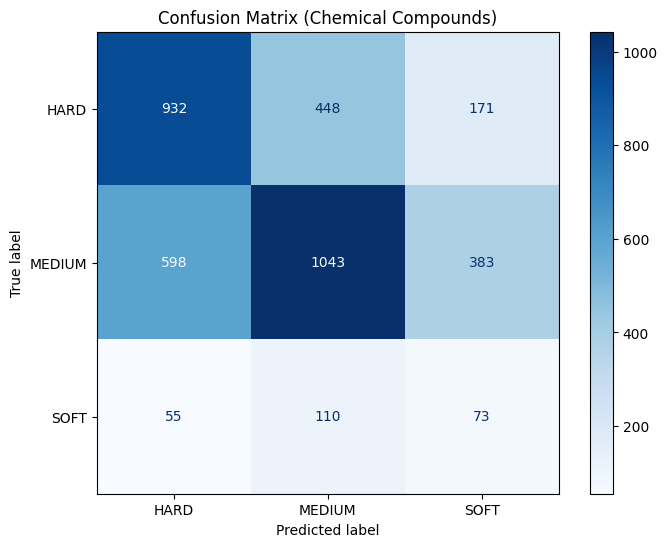


 XGBOOST DECISION TREE


/home/c/Desktop/AI_MUAR/ai_f1/.venv/lib/python3.13/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


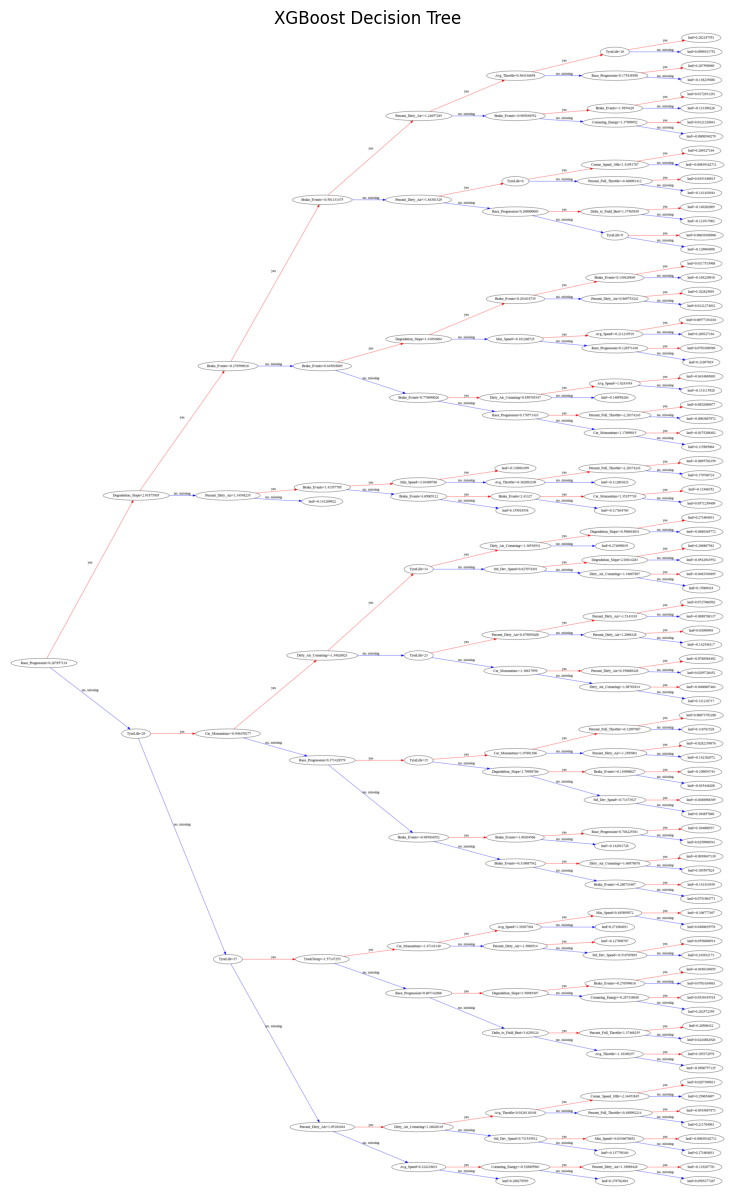


 SHAP INTERPRETABILITY


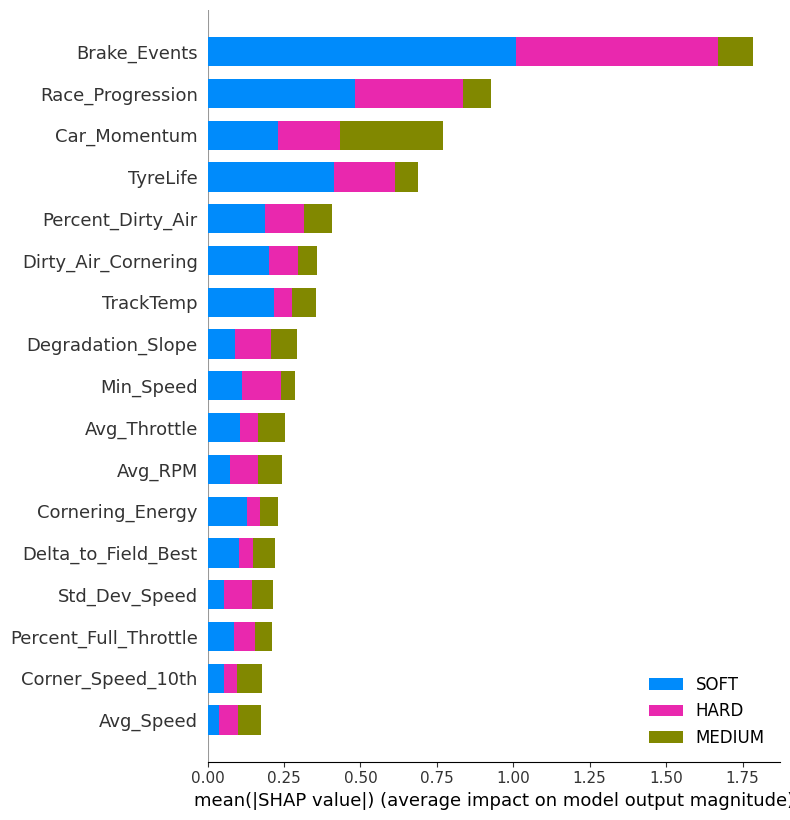

In [12]:
######################################################### EVALUATION ##############################################

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import shap
import matplotlib.pyplot as plt

X_test = pd.DataFrame(X_test.values, columns=X_train.columns)

# reverse_mapping = {0: 'C1', 1: 'C2', 2: 'C3', 3: 'C4', 4: 'C5', 5: 'C6'}
# target_names = [reverse_mapping[c] for c in final_model.classes_]
y_pred = final_model.predict(X_test)

# 1. Update the mapping to match your new Target_Encoded dictionary
reverse_mapping = {0: 'HARD', 1: 'MEDIUM', 2: 'SOFT'}

# 2. Extract target names dynamically based on what the model actually predicted
target_names = [reverse_mapping[c] for c in final_model.classes_]

print("\n CLASSIFICATION REPORT")
print(classification_report(
    y_test, 
    y_pred, 
    labels=final_model.classes_, 
    target_names=target_names, 
    zero_division=0
))

print("\n CONFUSION MATRIX")
cm_strict = confusion_matrix(y_test, y_pred, labels=final_model.classes_)
disp_strict = ConfusionMatrixDisplay(confusion_matrix=cm_strict, display_labels=target_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp_strict.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix (Chemical Compounds)")
plt.show()

print("\n XGBOOST DECISION TREE")
try:
    final_model.get_booster().feature_names = list(X_train.columns)
    fig, ax = plt.subplots(figsize=(30, 15)) 
    xgb.plot_tree(final_model, num_trees=0, ax=ax, rankdir='LR')
    plt.title("XGBoost Decision Tree")
    plt.show()
except Exception as e:
    print(f"Could not plot tree (Graphviz likely missing on OS level). Error: {e}")

print("\n SHAP INTERPRETABILITY")
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# Handle 3D SHAP arrays for multiclass classification
if len(np.array(shap_values).shape) == 3:
    shap_values_formatted = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
else:
    shap_values_formatted = shap_values

shap.summary_plot(
    shap_values_formatted, 
    X_test, 
    class_names=target_names, 
    plot_type="bar", 
    show=True
)